# Phase 5: JEPA

**Skill:** self-supervised world models, and keeping score honestly when the baseline is strong.

Phase 5 trains a JEPA (joint-embedding predictive architecture) on the ecosystem graph from Phase 4. It learns by predicting *latents*, never pixels or raw features. There were four steps:

1. **Static JEPA:** hide a block of patches in a snapshot and predict their latents from the rest. Evaluated with linear probes.
2. **Temporal JEPA:** predict the latents of the snapshot at t + 1, 7 and 30 days from the snapshot at t.
3. **Action-conditioned JEPA:** also tell the predictor which interventions and weather fall between t and t + k. Tested on spill-vs-no-spill counterfactuals.
4. **Collapse monitoring, a generative baseline, and Gate C:** does a JEPA backbone with prediction heads beat the supervised Phase 4 GNN at 7 and 30 days?

Everything below is loaded from the metrics files the training scripts wrote (`worldmodel/*_metrics.json`, `worldmodel/gate_c_*.json`). Nothing is retrained here, so the notebook runs in seconds. Splits are by world throughout: seeds 0–19 train, 20–23 select, and 24–27 are reported.

In [1]:
import os, sys, json
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import matplotlib.pyplot as plt
import numpy as np

W = Path("worldmodel")
load = lambda name: json.loads((W / name).read_text())
static, temporal, action = load("jepa_static_metrics.json"), load("jepa_temporal_metrics.json"), load("jepa_action_metrics.json")
generative, gate = load("generative_metrics.json"), load("gate_c_metrics.json")
H = (1, 7, 30)
%matplotlib inline

## 1. Static JEPA: does it learn anything without labels?

A context encoder sees a snapshot with about 30% of its patches hidden, in 2×2 and 3×3 blocks so a hidden patch can't simply be averaged from its neighbours. A predictor fills in what the **target encoder** makes of the hidden patches. The target encoder is an exponential moving average (EMA) of the context encoder and gets no gradient. The loss compares latents, so nothing is reconstructed.

To test it, freeze everything and fit ridge regressions (linear probes) from latents to the current biomass, contamination, moisture and fungal network. A probe can only read out what the latent already holds linearly.

masked {'jepa': 0.764, 'random': 0.376, 'raw': 0.545}
full {'jepa': 0.891, 'random': 0.918, 'raw': 0.903}


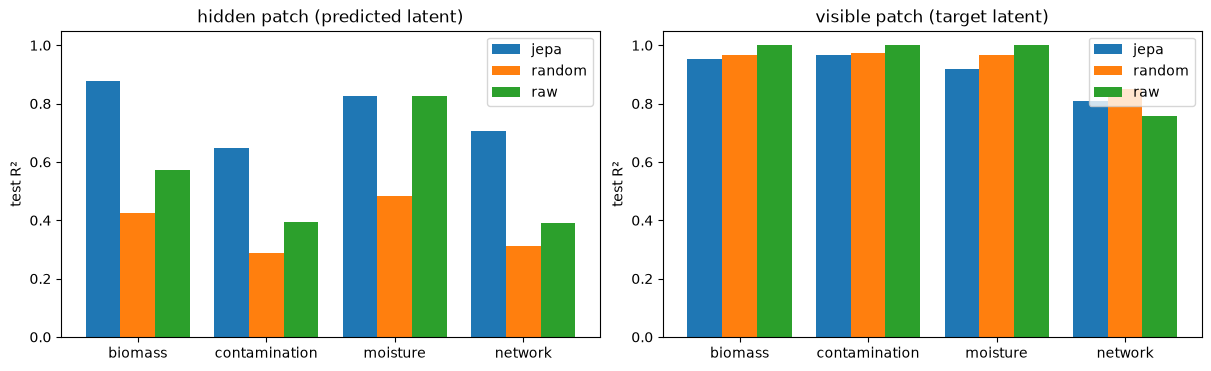

In [2]:
names = ["biomass", "contamination", "moisture", "network"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), constrained_layout=True)
for ax, setting, title in zip(axes, ["masked", "full"], ["hidden patch (predicted latent)", "visible patch (target latent)"]):
    for i, rep in enumerate(["jepa", "random", "raw"]):
        vals = [static[setting][rep][n]["test_r2"] for n in names]
        ax.bar(np.arange(4) + (i - 1) * 0.27, vals, 0.27, label=rep)
    ax.set_xticks(range(4), names); ax.set_ylim(0, 1.05); ax.set_title(title); ax.set_ylabel("test R²")
axes[0].legend(); axes[1].legend()
for s in ("masked", "full"):
    print(s, {r: round(static[s][r]["mean_test_r2"], 3) for r in ("jepa", "random", "raw")})

For a **hidden** patch, the JEPA's predicted latent beats both baselines: raw features of the visible 1-hop neighbours, and the same network untrained. It has learned how patches relate to their neighbours. Moisture is the exception: it is spatially smooth, so neighbours already give it away.

For a **visible** patch, the latents keep the state, but no better than a random network or the raw features themselves. The raw features *are* the quantities being probed, so that is a ceiling, not a contest.

## 2. Collapse: the failure a JEPA invites

A JEPA can trivially minimize its loss: map every patch to the same latent, and every prediction is perfect. Two statistics catch this on a batch of embeddings (`worldmodel/collapse.py`):

- **spread:** the mean per-dimension std divided by the embedding's RMS. It is scale-free, so a final LayerNorm can't hide collapse. It falls toward 0 when every row is the same vector.
- **effective rank:** exp(entropy of the normalized singular values) (RankMe). It falls toward 1 when the embeddings lie on a line.

Every trainer records both statistics each epoch. A test trains the static JEPA *without* the EMA target and stop-grad, and without the variance term. Its loss drops lower than the healthy run's and its context latents collapse; the monitor flags it.

static (target)        rank  38.1  spread 0.98  flagged: False
temporal (pred 7 d)    rank  34.6  spread 0.91  flagged: False
action (pred 7 d)      rank  39.1  spread 0.88  flagged: False
generative (pred 7 d)  rank  15.9  spread 0.62  flagged: False


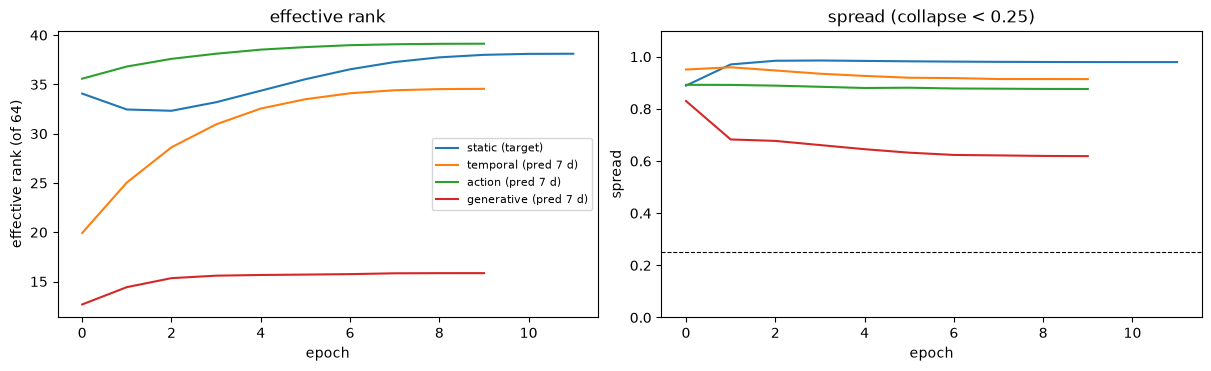

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), constrained_layout=True)
runs = {"static (target)": (static, "target"), "temporal (pred 7 d)": (temporal, "predicted_7d"),
        "action (pred 7 d)": (action, "predicted_7d"), "generative (pred 7 d)": (generative, "predicted_7d")}
for name, (m, key) in runs.items():
    hist = m["collapse_monitor"]["history"]
    axes[0].plot([h[key]["effective_rank"] for h in hist], label=name)
    axes[1].plot([h[key]["spread"] for h in hist], label=name)
axes[0].set(xlabel="epoch", ylabel="effective rank (of 64)", title="effective rank")
axes[1].set(xlabel="epoch", ylabel="spread", title="spread (collapse < 0.25)", ylim=(0, 1.1))
axes[1].axhline(0.25, color="k", lw=0.8, ls="--"); axes[0].legend(fontsize=8)
for name, (m, key) in runs.items():
    last = m["collapse_monitor"]["history"][-1][key]
    print(f"{name:<22} rank {last['effective_rank']:5.1f}  spread {last['spread']:.2f}  flagged: {m['collapse_monitor']['collapsed']}")

None of the shipped runs collapsed. The generative baseline is worth a second look: its predicted latents use only about 16 of 64 directions, against 35–40 for the JEPA. It has no collapse incentive, but regressing 14 input features doesn't need more.

## 3. Temporal JEPA: forecasting in latent space

The predictor now takes the latents at t (and t − 7 for the trend) plus a learned horizon embedding, and predicts the target encoder's latents of the snapshot at t + k. Both encoders start from the static checkpoint.

To test it, fit linear probes from the frozen predicted latents onto the Phase 4 forecast heads, and score them exactly as the GNN is scored: skill = 1 − error / persistence error.

**Die-back caveat.** Die-back is zero almost everywhere, so under MAE a constant "no die-back" probe already scores about 0.5 skill on it. That inflates every mean, so the without-die-back mean is the more honest number.

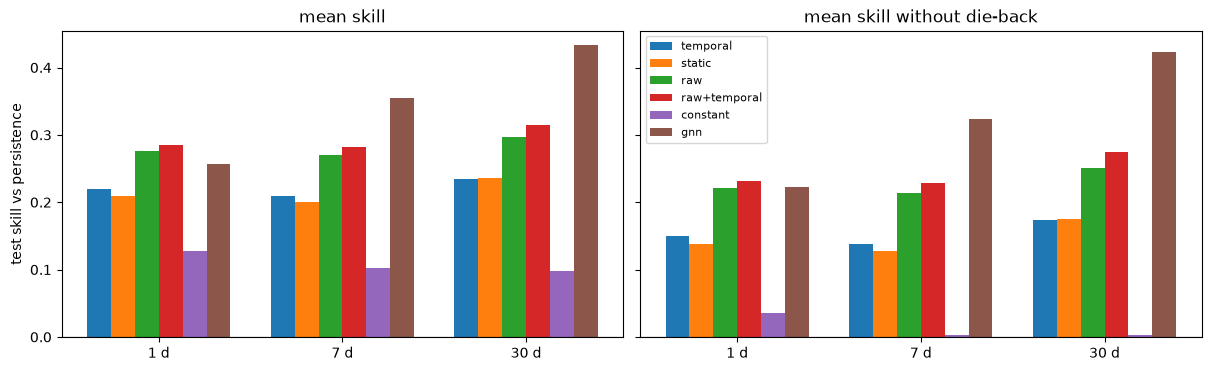

In [4]:
reps = ["temporal", "static", "raw", "raw+temporal", "constant"]
P = temporal["probes"]; G = temporal["gnn_test_means"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), constrained_layout=True, sharey=True)
for ax, key, title in zip(axes, ["mean_skill", "mean_skill_ex_mortality"], ["mean skill", "mean skill without die-back"]):
    for i, r in enumerate(reps + ["gnn"]):
        vals = [(P[r] if r != "gnn" else G)[f"{key}@{h}d"] for h in H]
        ax.bar(np.arange(3) + (i - 2.5) * 0.13, vals, 0.13, label=r)
    ax.set_xticks(range(3), [f"{h} d" for h in H]); ax.set_title(title); ax.axhline(0, color="k", lw=0.8)
axes[0].set_ylabel("test skill vs persistence"); axes[1].legend(fontsize=8)

Probed linearly, the temporal JEPA trails both a linear probe on the raw inputs and the supervised GNN. Its latents add only a little on top of the raw features. A linear probe on self-supervised latents isn't how the GNN is used, though, so section 6 trains real prediction heads.

## 4. Action-conditioned JEPA and counterfactuals

The predictor is now also told the **forcing** between t and t + k. That is every intervention in the window, per patch and kind (spill grams, carbon added, fraction disturbed, and so on), plus the window's mean weather. The new input paths start at zero, so an untrained action model is exactly the temporal model.

It is trained on a new dataset (`dataset.py --mode forcing`), with an intervention every 10 days and the applied intents recorded.

**Counterfactuals.** Each test world is replayed exactly to a branch day. The sim is copied, and both copies run 30 days with the same weather: one untouched, one with a spill. That gives 52 pairs. The true effect is the difference between the branches; the model's effect is the difference between its two predictions, decoded by the same frozen probes.

In [5]:
cf = action["counterfactual"]
rows = [("action", "contamination@7d (level probe)"), ("action", "contamination@30d (level probe)"),
        ("raw+forcing", "contamination@7d"), ("raw+forcing", "contamination@30d"),
        ("action", "biomass@30d (level probe)"), ("raw+forcing", "biomass@30d")]
print(f"{'model / effect':<45}{'skill':>8}{'sign':>7}{'size':>7}{'corr':>7}{'peak':>7}")
for rep, key in rows:
    r = cf[rep][key]
    print(f"{rep + ' / ' + key:<45}{r['effect_skill']:8.2f}{r['direction_agreement']:7.2f}"
          f"{r['magnitude_ratio']:7.2f}{r['spatial_corr']:7.2f}{r['peak_patch_found']:7.2f}")
print("step-2 temporal model: effect 0 by construction (it can't see the spill)")

model / effect                                  skill   sign   size   corr   peak
action / contamination@7d (level probe)          0.25   1.00   1.34   0.88   0.62
action / contamination@30d (level probe)         0.22   0.99   1.38   0.88   0.63
raw+forcing / contamination@7d                   0.17   1.00   0.24   0.83   0.58
raw+forcing / contamination@30d                  0.24   1.00   0.64   0.83   0.58
action / biomass@30d (level probe)              -4.33   0.57  -0.13   0.14   0.35
raw+forcing / biomass@30d                        0.12   1.00   0.56   0.83   0.88
step-2 temporal model: effect 0 by construction (it can't see the spill)


The JEPA latents **do** encode the spill. Read through a contamination-level probe, the predicted effect has the right sign almost everywhere and the right shape (correlation 0.88), but is 1.3–1.4× too large.

The honest takeaway, though: **a linear model given the same forcing does as well on contamination and much better on biomass.** There, the JEPA overshoots a tiny effect by roughly 6–20×. The JEPA hasn't yet learned anything about spills that a linear model can't read from the same inputs.

## 5. A generative baseline

Is the JEPA objective the reason for these numbers, or just the network? The generative baseline is the **same network**, with the same initialization, data, epochs and optimizer. Only the loss differs: it decodes each predicted latent to the normalized patch features at t + k and regresses them in input space.

In [6]:
gp = generative["probes_test"]
for name, src in [("temporal JEPA", P["temporal"]), ("generative", gp), ("raw", P["raw"])]:
    print(f"{name:<14}", "  ".join(f"{h}d {src[f'mean_skill@{h}d']:+.3f} / ex-mort {src[f'mean_skill_ex_mortality@{h}d']:+.3f}" for h in H))

temporal JEPA  1d +0.220 / ex-mort +0.151  7d +0.209 / ex-mort +0.138  30d +0.234 / ex-mort +0.173
generative     1d +0.231 / ex-mort +0.164  7d +0.223 / ex-mort +0.155  30d +0.287 / ex-mort +0.240
raw            1d +0.276 / ex-mort +0.221  7d +0.270 / ex-mort +0.214  30d +0.296 / ex-mort +0.251


Under the same linear probes, the generative baseline's latents are slightly *better* forecasting features than the JEPA's, especially at 30 days.

## 6. Gate C: prediction heads vs the GNN

**Gate C:** a JEPA model with prediction heads beats the GNN baseline at 7 and 30 days.

For a fair test, everything except the backbone follows the GNN's protocol:

- the same Phase 4 data (the GNN's training data), split, heads, loss and metric;
- model selection on the validation worlds;
- the same head design: a node head per horizon on [predicted latent at t + k, latent at t], and the GNN's link head with its persistence prior.

Each backbone is tried two ways:

- **frozen:** only the heads train, for 30 epochs like the GNN.
- **fine-tuned:** everything trains, with the backbone at a tenth of the learning rate, for 12 epochs (about the same wall time).

Backbones: the temporal JEPA, the generative baseline, and the same network from scratch.

The main sweep trains on every day, like the GNN (13,400 samples, about 7.5 min a run). A second sweep on every other day is shown too. The difference between the two is the closest thing here to error bars: each configuration ran once per sweep.

                                   1d       7d      30d   (ex die-back)
gnn (Phase 4, supervised)       0.257    0.355    0.433  0.223 0.324 0.423
temporal/frozen                 0.162    0.263    0.344  0.182 0.221 0.314
temporal/finetune               0.269    0.255    0.385  0.236 0.198 0.363
generative/frozen               0.215    0.333    0.426  0.187 0.298 0.414
generative/finetune             0.288    0.337    0.442  0.271 0.301 0.434
scratch/frozen                  0.278    0.292    0.356  0.229 0.242 0.325
scratch/finetune                0.291    0.304    0.412  0.269 0.261 0.397

Gate C passed: False {'temporal/frozen': {'7d': False, '30d': False}, 'temporal/finetune': {'7d': False, '30d': False}}

second sweep (every other training day):
temporal/frozen                 0.125    0.270    0.364  0.158 0.232 0.339
temporal/finetune               0.260    0.333    0.411  0.262 0.300 0.396
generative/frozen               0.271    0.348    0.432  0.236 0.314 0.421
generative/fine

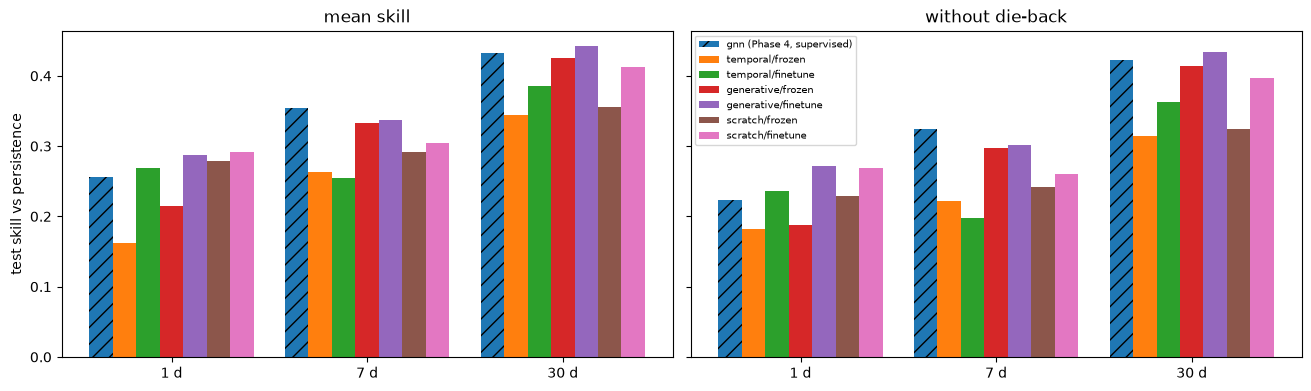

In [7]:
T = gate["table"]
names = list(T)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True, sharey=True)
for ax, key, title in zip(axes, ["mean_skill", "mean_skill_ex_mortality"], ["mean skill", "without die-back"]):
    for i, n in enumerate(names):
        ax.bar(np.arange(3) + (i - 3) * 0.12, [T[n][f"{key}@{h}d"] for h in H], 0.12, label=n,
               hatch="//" if n.startswith("gnn") else None)
    ax.set_xticks(range(3), [f"{h} d" for h in H]); ax.set_title(title)
axes[0].set_ylabel("test skill vs persistence"); axes[1].legend(fontsize=7, loc="upper left")
print(f"{'':<28}" + "".join(f"{h:>8}d" for h in H) + "   (ex die-back)")
for n in names:
    print(f"{n:<28}" + "".join(f"{T[n][f'mean_skill@{h}d']:9.3f}" for h in H)
          + "  " + " ".join(f"{T[n][f'mean_skill_ex_mortality@{h}d']:.3f}" for h in H))
print("\nGate C passed:", gate["gate_c_passed"], gate["jepa_vs_gnn"])
S2 = gate["other_sweeps"]["train_stride_2"]
print("\nsecond sweep (every other training day):")
for n in S2:
    print(f"{n:<28}" + "".join(f"{S2[n][f'mean_skill@{h}d']:9.3f}" for h in H)
          + "  " + " ".join(f"{S2[n][f'mean_skill_ex_mortality@{h}d']:.3f}" for h in H))

**Gate C is not met.** No JEPA run beats the GNN at 7 or 30 days, in either sweep. The best JEPA result is fine-tuned on every other day: 0.333 / 0.411 at 7 / 30 days, against the GNN's 0.355 / 0.433.

Why, from the numbers above:

1. **JEPA pretraining doesn't beat no pretraining.** Fine-tuned, the JEPA backbone and the same network from scratch land within run-to-run noise of each other. Each wins some horizons, and the order flips between sweeps. Frozen, the JEPA trails a frozen *random* network at 1 and 7 days in both sweeps. Its latents throw away some of what the heads need.
2. **Fine-tuning the JEPA is unstable.** In the every-day sweep its 7-day test skill (0.255) sits far below its validation skill (0.353). The gap comes from fungal links and contamination on the test worlds: links at 7 days drop to −0.32. Model selection on four validation worlds can't see it.
3. **The generative objective is the better pretraining here.** Same network, same budget: its frozen backbone comes close to the GNN (0.333 / 0.426 and 0.348 / 0.432 in the two sweeps). Fine-tuned, it is level with the GNN at 30 days in both sweeps (0.442 and 0.438 vs 0.433, inside the noise: one seed per configuration), and below it at 7. The heads read future biomass, contamination and moisture, and a backbone trained to reconstruct exactly those features carries them most directly. The JEPA latents are only asked to match an encoder's view of the future, and that encoder was shaped by masked-patch prediction, not by these targets.
4. **The GNN is a strong, cheap baseline.** At 64 nodes and 14 features per patch, there may be little that self-supervision can find which supervision on 13,400 labelled samples misses. JEPA's usual advantage, ignoring unpredictable detail in high-dimensional inputs such as pixels, has little to work with in a 14-number patch.
5. **Fungal links are where the backbones lose most to the GNN.** The fine-tuned JEPA trails the GNN on links by 0.51 at 7 days (0.24 at 30), and its 7-day links skill falls to -0.32 on the test worlds, which causes its validation/test gap; frozen backbones also lose on biomass. Contamination is close to the GNN for the fine-tuned backbones. The fine-tune budget was set by wall time (12 epochs, last epoch picked), so it may be undertrained.


The roadmap counts a write-up like this as a result. It also points to the next experiment: larger or less redundant inputs (cell-level fields rather than 8×8 patch means), where predicting in latent space has more to throw away. Repeated seeds would turn the run-to-run differences into real error bars.

## What broke

- **Raw features made the first probe meaningless.** A probe from latents to the *current* state can't beat the raw features, because they are that state. The masked probe, which reads the predicted latent of a hidden patch, is the test that can tell representations apart.
- **Die-back inflated every mean.** A constant "no die-back" probe scores about 0.5 skill under MAE. The step-2 numbers were first reported without saying so; every table now carries a without-die-back mean.
- **The first forecast probes were ridge (least squares), scored with MAE.** Mortality's skill came out at −0.27. Switching to least-absolute-deviation (LAD) probes, fit for the metric that is reported, fixed it.
- **A probe evaluation was killed for running out of memory** (about 6 GB). Representations were concatenated before subsampling; probes now gather rows piecewise.
- **The forecast probes hid what the action model knew.** LAD fits of mostly-zero changes barely react to a rare spill. A least-squares level probe showed the latents did encode it, but also that each representation needs a different decoder to look its best.
- **The first collapse monitor missed collapse.** The context encoder ends in a LayerNorm, so collapsing latents keep std ≈ 1 per dimension. The scale-free *spread* statistic catches it.
- **Gate C rankings moved between sweeps.** The first sweep trained heads on every other day and put the JEPA fine-tune ahead of scratch. Rerunning on every day, like the GNN, reversed that, and exposed a validation/test gap in the JEPA fine-tune. Both sweeps are reported. With one run per configuration, differences under about 0.03 are noise.
- **Phase 4 data had no record of its interventions.** Step 3 needed a new dataset mode. A hash test pins the Phase 4 mode to its original bytes.